In [1]:
import pandas as pd

file_path = "apple_global_sales_dataset.csv"
df = pd.read_csv(file_path)

df.head()

,sale_id,sale_date,year,quarter,month,country,region,city,product_name,category,...,currency,fx_rate_to_usd,revenue_local_currency,sales_channel,payment_method,customer_segment,customer_age_group,previous_device_os,customer_rating,return_status
0,APPL-00000001,2022-01-03,2022,Q1,January,Argentina,South America,Buenos Aires,AirPods (3rd Gen),AirPods,...,ARS,907.0,134344.84,Third-Party Retailer,Cash,Government,45–54,NaN,4.1,Kept
1,APPL-00000002,2022-01-04,2022,Q1,January,Argentina,South America,Buenos Aires,USB-C Woven Charge Cable,Accessories,...,ARS,907.0,115597.15,Authorized Reseller,Debit Card,Business,45–54,NaN,4.8,Kept
2,APPL-00000003,2022-05-18,2022,Q2,May,Argentina,South America,Buenos Aires,Apple Watch Series 8,Apple Watch,...,ARS,907.0,1066341.76,Corporate / B2B,Credit Card,Individual,18–24,NaN,4.3,Kept
3,APPL-00000004,2022-05-23,2022,Q2,May,Argentina,South America,Buenos Aires,MacBook Pro 14-inch (M3),Mac,...,ARS,907.0,3506044.78,Carrier Store,Credit Card,Education,45–54,NaN,NaN,Kept
4,APPL-00000005,2022-07-13,2022,Q3,July,Argentina,South America,Buenos Aires,Apple Watch Ultra 2,Apple Watch,...,ARS,907.0,1952780.07,Apple Store,Net Banking,Education,18–24,NaN,NaN,Kept


In [2]:
df = pd.read_csv("apple_global_sales_dataset.csv")

df["sale_date"] = pd.to_datetime(df["sale_date"])

df = df.drop(columns=[
    "sale_id",
    "revenue_local_currency",
    "discounted_price_usd",
    "currency"
])

In [3]:
df = df[(df["discount_pct"] >= 0) & (df["discount_pct"] <= 100)]

In [4]:
df["previous_device_os"] = df["previous_device_os"].fillna("Unknown")
df["storage"] = df["storage"].fillna("Unknown")

In [5]:
df["customer_rating"] = df["customer_rating"].fillna(df["customer_rating"].median())

In [6]:
df["return_binary"] = df["return_status"].apply(
    lambda x: 1 if x in ["Returned", "Exchanged"] else 0
)

In [7]:
df = df.drop(columns=["return_status"])

In [8]:
print(df.shape)
df.head()

(11500, 23)


,sale_date,year,quarter,month,country,region,city,product_name,category,storage,...,units_sold,revenue_usd,fx_rate_to_usd,sales_channel,payment_method,customer_segment,customer_age_group,previous_device_os,customer_rating,return_binary
0,2022-01-03,2022,Q1,January,Argentina,South America,Buenos Aires,AirPods (3rd Gen),AirPods,Unknown,...,1,148.12,907.0,Third-Party Retailer,Cash,Government,45–54,Unknown,4.1,0
1,2022-01-04,2022,Q1,January,Argentina,South America,Buenos Aires,USB-C Woven Charge Cable,Accessories,Unknown,...,5,127.45,907.0,Authorized Reseller,Debit Card,Business,45–54,Unknown,4.8,0
2,2022-05-18,2022,Q2,May,Argentina,South America,Buenos Aires,Apple Watch Series 8,Apple Watch,Unknown,...,4,1175.68,907.0,Corporate / B2B,Credit Card,Individual,18–24,Unknown,4.3,0
3,2022-05-23,2022,Q2,May,Argentina,South America,Buenos Aires,MacBook Pro 14-inch (M3),Mac,1 TB SSD,...,2,3865.54,907.0,Carrier Store,Credit Card,Education,45–54,Unknown,4.0,0
4,2022-07-13,2022,Q3,July,Argentina,South America,Buenos Aires,Apple Watch Ultra 2,Apple Watch,Unknown,...,3,2153.01,907.0,Apple Store,Net Banking,Education,18–24,Unknown,4.0,0


In [9]:
# 1. Remove revenue_usd to avoid leakage
df = df.drop(columns=["revenue_usd"])

# 2. Extract additional time features
df["day_of_week"] = df["sale_date"].dt.dayofweek
df["is_weekend"] = df["day_of_week"].apply(lambda x: 1 if x >= 5 else 0)

# 3. Price pressure feature
df["price_after_discount"] = df["unit_price_usd"] * (1 - df["discount_pct"] / 100)

# 4. Revenue proxy (unit_price × units)
df["gross_value"] = df["unit_price_usd"] * df["units_sold"]

# 5. Drop raw date (model gak perlu timestamp mentah)
df = df.drop(columns=["sale_date"])

print(df.shape)
df.head()

(11500, 25)


,year,quarter,month,country,region,city,product_name,category,storage,color,...,payment_method,customer_segment,customer_age_group,previous_device_os,customer_rating,return_binary,day_of_week,is_weekend,price_after_discount,gross_value
0,2022,Q1,January,Argentina,South America,Buenos Aires,AirPods (3rd Gen),AirPods,Unknown,Starlight,...,Cash,Government,45–54,Unknown,4.1,0,0,0,148.1211,159.27
1,2022,Q1,January,Argentina,South America,Buenos Aires,USB-C Woven Charge Cable,Accessories,Unknown,Black,...,Debit Card,Business,45–54,Unknown,4.8,0,1,0,25.4915,149.95
2,2022,Q2,May,Argentina,South America,Buenos Aires,Apple Watch Series 8,Apple Watch,Unknown,Titanium,...,Credit Card,Individual,18–24,Unknown,4.3,0,2,0,293.9200,1175.68
3,2022,Q2,May,Argentina,South America,Buenos Aires,MacBook Pro 14-inch (M3),Mac,1 TB SSD,Starlight,...,Credit Card,Education,45–54,Unknown,4.0,0,0,0,1932.7700,3865.54
4,2022,Q3,July,Argentina,South America,Buenos Aires,Apple Watch Ultra 2,Apple Watch,Unknown,Midnight,...,Net Banking,Education,18–24,Unknown,4.0,0,2,0,717.6680,2266.32


In [10]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

# Define target
y = df["return_binary"]
X = df.drop(columns=["return_binary"])

# Train test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

numeric_cols = X_train.select_dtypes(include=np.number).columns
categorical_cols = X_train.select_dtypes(include="object").columns

encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

X_train_cat = encoder.fit_transform(X_train[categorical_cols])
X_test_cat = encoder.transform(X_test[categorical_cols])

# Combine numeric + encoded categorical
X_train_final = np.hstack([X_train[numeric_cols].values, X_train_cat])
X_test_final = np.hstack([X_test[numeric_cols].values, X_test_cat])

print("Train shape:", X_train_final.shape)
print("Test shape:", X_test_final.shape)
print("Target distribution (train):")
print(y_train.value_counts(normalize=True))

Train shape: (9200, 704)
Test shape: (2300, 704)
Target distribution (train):
return_binary
0    0.881957
1    0.118043
Name: proportion, dtype: float64


In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

model.fit(X_train_final, y_train)

y_pred = model.predict(X_test_final)
y_prob = model.predict_proba(X_test_final)[:, 1]

print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

print("ROC-AUC:", roc_auc_score(y_test, y_prob))

Confusion Matrix
[[1130  899]
 [ 153  118]]

Classification Report
              precision    recall  f1-score   support

           0       0.88      0.56      0.68      2029
           1       0.12      0.44      0.18       271

    accuracy                           0.54      2300
   macro avg       0.50      0.50      0.43      2300
weighted avg       0.79      0.54      0.62      2300

ROC-AUC: 0.49246625043874886


C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_final, y_train)

y_pred_rf = rf.predict(X_test_final)
y_prob_rf = rf.predict_proba(X_test_final)[:, 1]

print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report")
print(classification_report(y_test, y_pred_rf))

print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

Confusion Matrix
[[1831  198]
 [ 248   23]]

Classification Report
              precision    recall  f1-score   support

           0       0.88      0.90      0.89      2029
           1       0.10      0.08      0.09       271

    accuracy                           0.81      2300
   macro avg       0.49      0.49      0.49      2300
weighted avg       0.79      0.81      0.80      2300

ROC-AUC: 0.5083666903697129


### Gradient Boosting ###

In [13]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

gb = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb.fit(X_train_final, y_train)

y_pred_gb = gb.predict(X_test_final)
y_prob_gb = gb.predict_proba(X_test_final)[:, 1]

print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred_gb))

print("\nClassification Report")
print(classification_report(y_test, y_pred_gb))

print("ROC-AUC:", roc_auc_score(y_test, y_prob_gb))

Confusion Matrix
[[2027    2]
 [ 271    0]]

Classification Report
              precision    recall  f1-score   support

           0       0.88      1.00      0.94      2029
           1       0.00      0.00      0.00       271

    accuracy                           0.88      2300
   macro avg       0.44      0.50      0.47      2300
weighted avg       0.78      0.88      0.83      2300

ROC-AUC: 0.5030498727855687


In [14]:
import pandas as pd

# Cek return rate per category
print("Return rate by category")
print(df.groupby("category")["return_binary"].mean().sort_values(ascending=False))

print("\nReturn rate by sales_channel")
print(df.groupby("sales_channel")["return_binary"].mean().sort_values(ascending=False))

print("\nReturn rate by payment_method")
print(df.groupby("payment_method")["return_binary"].mean().sort_values(ascending=False))

print("\nReturn rate by customer_segment")
print(df.groupby("customer_segment")["return_binary"].mean().sort_values(ascending=False))

Return rate by category
category
Mac            0.124933
iPad           0.122553
AirPods        0.122295
iPhone         0.120209
Apple Watch    0.112789
Accessories    0.108222
Name: return_binary, dtype: float64

Return rate by sales_channel
sales_channel
Authorized Reseller     0.124675
Online (Apple.com)      0.119588
Carrier Store           0.117371
Apple Store             0.115987
Third-Party Retailer    0.115751
Corporate / B2B         0.114540
Name: return_binary, dtype: float64

Return rate by payment_method
payment_method
Net Banking          0.127900
Cash                 0.124378
Apple Pay            0.120249
Debit Card           0.118885
EMI / Installment    0.118572
Gift Card            0.110574
Credit Card          0.105764
Name: return_binary, dtype: float64

Return rate by customer_segment
customer_segment
Education     0.125173
Business      0.121169
Individual    0.118198
Government    0.107538
Name: return_binary, dtype: float64


### REDUCE NOISE FEATURES ###

In [15]:
df_reduced = df.drop(columns=[
    "city",
    "product_name",
    "color",
    "year",
    "month"
])

# Redefine split
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
import numpy as np

y = df_reduced["return_binary"]
X = df_reduced.drop(columns=["return_binary"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

numeric_cols = X_train.select_dtypes(include=np.number).columns
categorical_cols = X_train.select_dtypes(include="object").columns

encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

X_train_cat = encoder.fit_transform(X_train[categorical_cols])
X_test_cat = encoder.transform(X_test[categorical_cols])

X_train_final = np.hstack([X_train[numeric_cols].values, X_train_cat])
X_test_final = np.hstack([X_test[numeric_cols].values, X_test_cat])

print("New train shape:", X_train_final.shape)

New train shape: (9200, 114)


### RANDOM FOREST ###

In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

rf = RandomForestClassifier(
    n_estimators=400,
    max_depth=15,
    min_samples_split=8,
    min_samples_leaf=4,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_final, y_train)

y_pred_rf = rf.predict(X_test_final)
y_prob_rf = rf.predict_proba(X_test_final)[:, 1]

print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report")
print(classification_report(y_test, y_pred_rf))

print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

Confusion Matrix
[[2019   10]
 [ 271    0]]

Classification Report
              precision    recall  f1-score   support

           0       0.88      1.00      0.93      2029
           1       0.00      0.00      0.00       271

    accuracy                           0.88      2300
   macro avg       0.44      0.50      0.47      2300
weighted avg       0.78      0.88      0.82      2300

ROC-AUC: 0.5084758092529176


### Target Baru ###

In [17]:
import pandas as pd
import numpy as np

df = pd.read_csv("apple_global_sales_dataset.csv")
df["sale_date"] = pd.to_datetime(df["sale_date"])
df = df.drop(columns=["sale_id", "revenue_local_currency", "currency"])

# Handle missing
df["previous_device_os"] = df["previous_device_os"].fillna("Unknown")
df["storage"] = df["storage"].fillna("Unknown")
df["customer_rating"] = df["customer_rating"].fillna(df["customer_rating"].median())

# Feature engineering
df["day_of_week"] = df["sale_date"].dt.dayofweek
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

# Define target
y = df["revenue_usd"]

# Remove leakage feature directly derived from revenue
df = df.drop(columns=["revenue_usd", "discounted_price_usd"])

X = df.drop(columns=["sale_date"])

print(X.shape)
print(y.describe())

(11500, 23)
count    11500.000000
mean      1568.319065
std       2839.759822
min         23.000000
25%        305.740000
50%        833.040000
75%       1748.360000
max      59529.520000
Name: revenue_usd, dtype: float64


### SPLIT + ENCODING (REGRESSION) ###

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

# Log transform feature
y_log = np.log1p(y)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_log,
    test_size=0.2,
    random_state=42
)

numeric_cols = X_train.select_dtypes(include=np.number).columns
categorical_cols = X_train.select_dtypes(include="object").columns

encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

X_train_cat = encoder.fit_transform(X_train[categorical_cols])
X_test_cat = encoder.transform(X_test[categorical_cols])

X_train_final = np.hstack([X_train[numeric_cols].values, X_train_cat])
X_test_final = np.hstack([X_test[numeric_cols].values, X_test_cat])

print("Train shape:", X_train_final.shape)
print("Test shape:", X_test_final.shape)

Train shape: (9200, 705)
Test shape: (2300, 705)


### RANDOM FOREST REGRESSOR ###

In [19]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

rf = RandomForestRegressor(
    n_estimators=400,
    max_depth=18,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_final, y_train)

y_pred_log = rf.predict(X_test_final)

# Convert back from log scale
y_pred = np.expm1(y_pred_log)
y_true = np.expm1(y_test)

print("R2:", r2_score(y_true, y_pred))
print("MAE:", mean_absolute_error(y_true, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))

R2: 0.9873483453048495
MAE: 31.20637810906126
RMSE: 301.23105508082784


### REMOVE LEAKAGE SOURCE ###

In [20]:
X_no_leak = X.drop(columns=["units_sold"])

X_train, X_test, y_train, y_test = train_test_split(
    X_no_leak,
    y_log,
    test_size=0.2,
    random_state=42
)

numeric_cols = X_train.select_dtypes(include=np.number).columns
categorical_cols = X_train.select_dtypes(include="object").columns

encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

X_train_cat = encoder.fit_transform(X_train[categorical_cols])
X_test_cat = encoder.transform(X_test[categorical_cols])

X_train_final = np.hstack([X_train[numeric_cols].values, X_train_cat])
X_test_final = np.hstack([X_test[numeric_cols].values, X_test_cat])

rf.fit(X_train_final, y_train)

y_pred_log = rf.predict(X_test_final)

y_pred = np.expm1(y_pred_log)
y_true = np.expm1(y_test)

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

print("R2:", r2_score(y_true, y_pred))
print("MAE:", mean_absolute_error(y_true, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))

R2: 0.49762996186551756
MAE: 758.4411469996201
RMSE: 1898.1824020681397


### DEMAND PREDICTION SETUP ###


In [21]:
df = pd.read_csv("apple_global_sales_dataset.csv")

df["sale_date"] = pd.to_datetime(df["sale_date"])

df = df.drop(columns=[
    "sale_id",
    "revenue_usd",
    "revenue_local_currency",
    "currency",
    "discounted_price_usd"
])

df["previous_device_os"] = df["previous_device_os"].fillna("Unknown")
df["storage"] = df["storage"].fillna("Unknown")
df["customer_rating"] = df["customer_rating"].fillna(df["customer_rating"].median())

df["day_of_week"] = df["sale_date"].dt.dayofweek
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

y = df["units_sold"]
X = df.drop(columns=["units_sold", "sale_date"])

print(X.shape)
print(y.describe())

(11500, 22)
count    11500.000000
mean         2.023478
std          1.443599
min          1.000000
25%          1.000000
50%          1.000000
75%          3.000000
max          8.000000
Name: units_sold, dtype: float64


### DEMAND CLASSIFICATION SETUP ###

In [22]:
def demand_bucket(x):
    if x == 1:
        return 0  # low
    elif x <= 3:
        return 1  # medium
    else:
        return 2  # high

df["demand_class"] = df["units_sold"].apply(demand_bucket)

y = df["demand_class"]
X = df.drop(columns=["units_sold", "demand_class"])

print(y.value_counts(normalize=True))

demand_class
0    0.501130
1    0.370087
2    0.128783
Name: proportion, dtype: float64


### DEMAND CLASSIFICATION MODEL ###

In [23]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Encode
numeric_cols = X_train.select_dtypes(include=np.number).columns
categorical_cols = X_train.select_dtypes(include="object").columns

encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

X_train_cat = encoder.fit_transform(X_train[categorical_cols])
X_test_cat = encoder.transform(X_test[categorical_cols])

X_train_final = np.hstack([X_train[numeric_cols].values, X_train_cat])
X_test_final = np.hstack([X_test[numeric_cols].values, X_test_cat])

# Model
rf = RandomForestClassifier(
    n_estimators=400,
    max_depth=18,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_final, y_train)

y_pred = rf.predict(X_test_final)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report")
print(classification_report(y_test, y_pred))

Accuracy: 0.4043478260869565

Confusion Matrix
[[632 420 101]
 [502 279  70]
 [174 103  19]]

Classification Report
              precision    recall  f1-score   support

           0       0.48      0.55      0.51      1153
           1       0.35      0.33      0.34       851
           2       0.10      0.06      0.08       296

    accuracy                           0.40      2300
   macro avg       0.31      0.31      0.31      2300
weighted avg       0.38      0.40      0.39      2300



### AGGREGATED MONTHLY DEMAND ###

In [24]:
df_full = pd.read_csv("apple_global_sales_dataset.csv")
df_full["sale_date"] = pd.to_datetime(df_full["sale_date"])

df_full["year_month"] = df_full["sale_date"].dt.to_period("M")

agg = (
    df_full
    .groupby(["year_month", "product_name"])["units_sold"]
    .sum()
    .reset_index()
)

print(agg.head())
print("Rows:", agg.shape)

  year_month            product_name  units_sold
0    2022-01       AirPods (2nd Gen)          17
1    2022-01       AirPods (3rd Gen)          10
2    2022-01             AirPods Max          14
3    2022-01   AirPods Pro (2nd Gen)          15
4    2022-01  Apple Pencil (1st Gen)          10
Rows: (1547, 3)


### TIME FEATURE ###

In [25]:
import pandas as pd
import numpy as np

agg["year_month"] = agg["year_month"].astype(str)
agg["year"] = pd.to_datetime(agg["year_month"]).dt.year
agg["month"] = pd.to_datetime(agg["year_month"]).dt.month

# Sort for lag
agg = agg.sort_values(["product_name", "year", "month"])

# Lag 1 month demand per product
agg["lag_1"] = agg.groupby("product_name")["units_sold"].shift(1)

# Drop first month per product (NaN lag)
agg = agg.dropna()

print(agg.head())
print("Rows after lag:", agg.shape)

    year_month       product_name  units_sold  year  month  lag_1
43     2022-02  AirPods (2nd Gen)          16  2022      2   17.0
86     2022-03  AirPods (2nd Gen)          30  2022      3   16.0
129    2022-04  AirPods (2nd Gen)           7  2022      4   30.0
172    2022-05  AirPods (2nd Gen)          19  2022      5    7.0
215    2022-06  AirPods (2nd Gen)          16  2022      6   19.0
Rows after lag: (1504, 6)


### TIME-AWARE SPLIT ###

In [26]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
import numpy as np

# Sort by time
agg = agg.sort_values(["year", "month"])

# Split: train = before 2024, test = 2024
train = agg[agg["year"] < 2024]
test = agg[agg["year"] == 2024]

y_train = train["units_sold"]
y_test = test["units_sold"]

X_train = train.drop(columns=["units_sold", "year_month"])
X_test = test.drop(columns=["units_sold", "year_month"])

# Encode product_name
categorical_cols = ["product_name"]
numeric_cols = ["year", "month", "lag_1"]

encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

X_train_cat = encoder.fit_transform(X_train[categorical_cols])
X_test_cat = encoder.transform(X_test[categorical_cols])

X_train_final = np.hstack([X_train[numeric_cols].values, X_train_cat])
X_test_final = np.hstack([X_test[numeric_cols].values, X_test_cat])

# Model
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_final, y_train)

y_pred = rf.predict(X_test_final)

print("R2:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2: -0.04946585787888691
MAE: 5.475658764113313
RMSE: 7.100487411098598


In [27]:
# CHECK TEMPORAL SIGNAL

print("Correlation lag_1 vs units_sold:")
print(agg["lag_1"].corr(agg["units_sold"]))

print("\nBaseline R2 (mean predictor):")

mean_pred = np.full_like(y_test, y_train.mean(), dtype=float)
from sklearn.metrics import r2_score
print(r2_score(y_test, mean_pred))

Correlation lag_1 vs units_sold:
-0.016939241100841124

Baseline R2 (mean predictor):
-0.004371508319973794


In [28]:
import pandas as pd

df = pd.read_csv("apple_global_sales_dataset.csv")

category_revenue = (
    df.groupby("category")["revenue_usd"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

category_revenue["contribution_pct"] = (
    category_revenue["revenue_usd"] /
    category_revenue["revenue_usd"].sum()
) * 100

print(category_revenue)

      category  revenue_usd  contribution_pct
0          Mac   8369961.42         46.407823
1       iPhone   5734154.34         31.793410
2         iPad   1829815.70         10.145538
3  Apple Watch    958773.70          5.315986
4      AirPods    572773.95          3.175784
5  Accessories    570190.14          3.161458


### CHANNEL PERFORMANCE ###

In [29]:
channel_perf = (
    df.groupby("sales_channel")
    .agg(
        total_revenue=("revenue_usd", "sum"),
        total_units=("units_sold", "sum"),
        avg_order_value=("revenue_usd", "mean")
    )
    .sort_values("total_revenue", ascending=False)
    .reset_index()
)

channel_perf["revenue_pct"] = (
    channel_perf["total_revenue"] /
    channel_perf["total_revenue"].sum()
) * 100

print(channel_perf)

          sales_channel  total_revenue  total_units  avg_order_value  \
0         Carrier Store     3189039.91         3960      1663.557595   
1    Online (Apple.com)     3121857.55         3868      1609.204923   
2           Apple Store     2993323.16         3856      1563.909697   
3  Third-Party Retailer     2987135.57         3969      1578.824297   
4       Corporate / B2B     2901069.90         3736      1517.295973   
5   Authorized Reseller     2843243.16         3881      1477.009434   

   revenue_pct  
0    17.681850  
1    17.309352  
2    16.596685  
3    16.562377  
4    16.085180  
5    15.764556  


### CUSTOMER SEGMENT ANALYSIS ###

In [30]:
segment_perf = (
    df.groupby("customer_segment")
    .agg(
        total_revenue=("revenue_usd", "sum"),
        total_units=("units_sold", "sum"),
        avg_order_value=("revenue_usd", "mean")
    )
    .sort_values("total_revenue", ascending=False)
    .reset_index()
)

segment_perf["revenue_pct"] = (
    segment_perf["total_revenue"] /
    segment_perf["total_revenue"].sum()
) * 100

print(segment_perf)

  customer_segment  total_revenue  total_units  avg_order_value  revenue_pct
0        Education     4635788.76         5760      1607.416352    25.703447
1       Government     4493435.53         5882      1553.746725    24.914160
2         Business     4455761.84         5771      1569.482860    24.705276
3       Individual     4450683.12         5857      1542.697789    24.677117


### TOP PRODUCT REVENUE ###

In [31]:
product_perf = (
    df.groupby("product_name")["revenue_usd"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

product_perf["revenue_pct"] = (
    product_perf["revenue_usd"] /
    product_perf["revenue_usd"].sum()
) * 100

print(product_perf.head(10))

                   product_name  revenue_usd  revenue_pct
0            Mac Pro (M2 Ultra)   3724222.55    20.649206
1  MacBook Pro 16-inch (M3 Pro)   1491289.26     8.268555
2      MacBook Pro 14-inch (M3)   1027383.82     5.696400
3      MacBook Air 13-inch (M2)    634573.15     3.518434
4             iMac 24-inch (M3)    624597.43     3.463123
5             iPhone 13 Pro Max    605116.33     3.355109
6             iPhone 15 Pro Max    597448.92     3.312596
7      MacBook Air 15-inch (M2)    556390.06     3.084943
8       iPad Pro 12.9-inch (M2)    538088.68     2.983469
9                 iPhone 14 Pro    525599.32     2.914221


In [32]:
import numpy as np

shares = product_perf["revenue_pct"] / 100
hhi = np.sum(shares ** 2)

print("HHI:", hhi)

HHI: 0.06820718311443129


### COUNTRY PERFORMANCE ###

In [33]:
country_perf = (
    df.groupby("country")
    .agg(
        total_revenue=("revenue_usd", "sum"),
        total_units=("units_sold", "sum"),
        avg_order_value=("revenue_usd", "mean")
    )
    .sort_values("total_revenue", ascending=False)
    .reset_index()
)

country_perf["revenue_pct"] = (
    country_perf["total_revenue"] /
    country_perf["total_revenue"].sum()
) * 100

print(country_perf.head(10))

        country  total_revenue  total_units  avg_order_value  revenue_pct
0     Hong Kong      485261.23          530      1910.477283     2.690564
1   Netherlands      455560.33          509      1814.981394     2.525885
2        Mexico      454405.84          550      1689.241041     2.519484
3        Canada      451801.06          537      1704.909660     2.505042
4        Turkey      450007.23          533      1851.881605     2.495096
5  Saudi Arabia      444411.63          494      1828.854444     2.464071
6       Germany      444195.10          494      1783.916064     2.462870
7         Japan      440942.04          576      1609.277518     2.444833
8      Malaysia      432614.73          547      1683.325798     2.398662
9   South Korea      429516.44          490      1704.430317     2.381483


### REGION PERFORMANCE ###

In [34]:
region_perf = (
    df.groupby("region")
    .agg(
        total_revenue=("revenue_usd", "sum"),
        total_units=("units_sold", "sum"),
        avg_order_value=("revenue_usd", "mean")
    )
    .sort_values("total_revenue", ascending=False)
    .reset_index()
)

region_perf["revenue_pct"] = (
    region_perf["total_revenue"] /
    region_perf["total_revenue"].sum()
) * 100

print(region_perf)

          region  total_revenue  total_units  avg_order_value  revenue_pct
0         Europe     6210935.78         7849      1593.364746    34.436958
1           Asia     5432379.44         6972      1581.478731    30.120199
2  South America     1418014.98         1997      1432.338364     7.862281
3         Africa     1379004.44         1905      1462.358897     7.645984
4  North America     1186765.39         1528      1557.434895     6.580102
5    Middle East      814583.85          970      1676.098457     4.516516
6    Europe/Asia      800714.79         1036      1668.155813     4.439618
7        Oceania      793270.58         1013      1567.728419     4.398343


### EFFECTIVE PRICE PER UNIT ###

In [35]:
region_perf["revenue_per_unit"] = (
    region_perf["total_revenue"] /
    region_perf["total_units"]
)

print(region_perf[["region", "revenue_per_unit"]].sort_values("revenue_per_unit", ascending=False))

          region  revenue_per_unit
5    Middle East        839.777165
0         Europe        791.302813
7        Oceania        783.090405
1           Asia        779.170889
4  North America        776.678920
6    Europe/Asia        772.890724
3         Africa        723.886845
2  South America        710.072599


### PRODUCT MIX BY REGION ###

In [36]:
mix = (
    df.groupby(["region", "category"])["revenue_usd"]
    .sum()
    .reset_index()
)

total_region = mix.groupby("region")["revenue_usd"].transform("sum")

mix["pct"] = mix["revenue_usd"] / total_region * 100

print(
    mix.sort_values(["region", "pct"], ascending=[True, False])
)

           region     category  revenue_usd        pct
3          Africa          Mac    610980.11  44.305884
5          Africa       iPhone    462606.72  33.546427
4          Africa         iPad    144040.93  10.445284
2          Africa  Apple Watch     69393.22   5.032124
0          Africa  Accessories     49765.73   3.608816
1          Africa      AirPods     42217.73   3.061464
9            Asia          Mac   2495530.76  45.938079
11           Asia       iPhone   1786084.43  32.878492
10           Asia         iPad    528026.47   9.719985
8            Asia  Apple Watch    303388.78   5.584823
7            Asia      AirPods    160973.53   2.963223
6            Asia  Accessories    158375.47   2.915398
15         Europe          Mac   2967838.90  47.784086
17         Europe       iPhone   1923851.22  30.975223
16         Europe         iPad    618349.95   9.955826
14         Europe  Apple Watch    293724.06   4.729143
13         Europe      AirPods    215971.46   3.477277
12        

### DATA VISUALIZATION ###

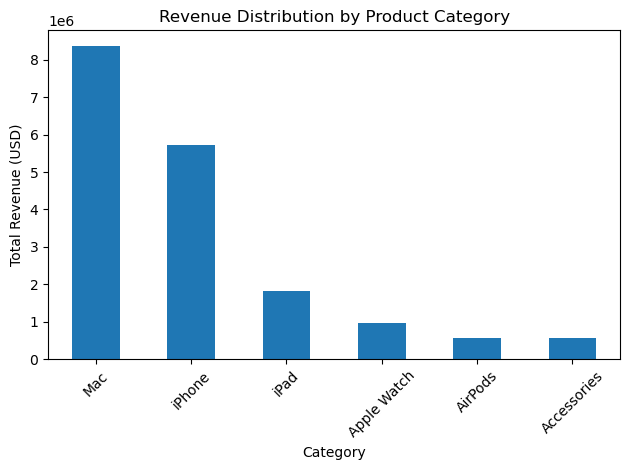

In [37]:
import matplotlib.pyplot as plt

category_revenue = (
    df.groupby("category")["revenue_usd"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure()
category_revenue.plot(kind="bar")
plt.title("Revenue Distribution by Product Category")
plt.xlabel("Category")
plt.ylabel("Total Revenue (USD)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

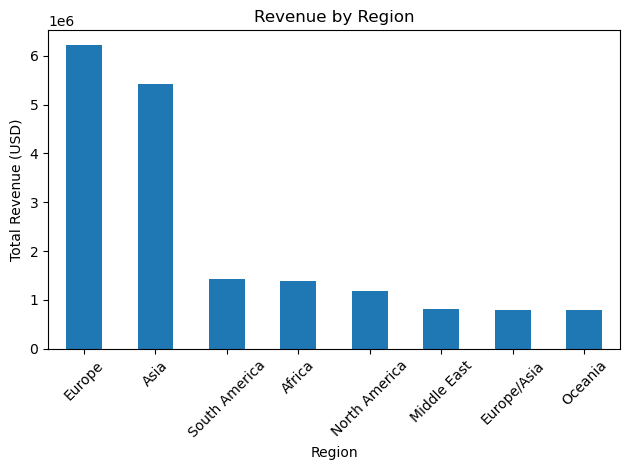

In [38]:
region_revenue = (
    df.groupby("region")["revenue_usd"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure()
region_revenue.plot(kind="bar")
plt.title("Revenue by Region")
plt.xlabel("Region")
plt.ylabel("Total Revenue (USD)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

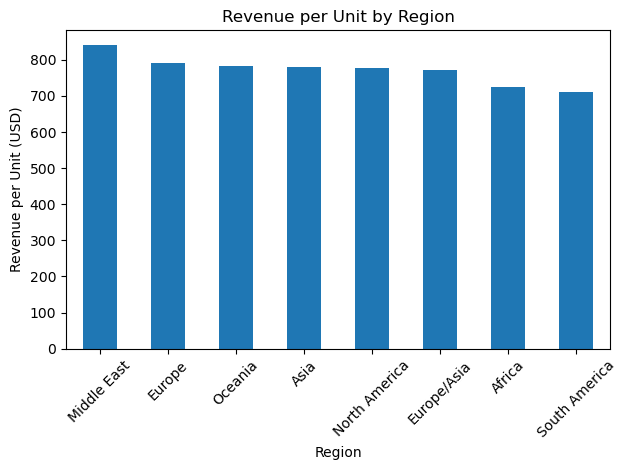

In [39]:
region_perf = df.groupby("region").agg(
    total_revenue=("revenue_usd", "sum"),
    total_units=("units_sold", "sum")
)

region_perf["revenue_per_unit"] = (
    region_perf["total_revenue"] /
    region_perf["total_units"]
)

region_perf = region_perf.sort_values("revenue_per_unit", ascending=False)

plt.figure()
region_perf["revenue_per_unit"].plot(kind="bar")
plt.title("Revenue per Unit by Region")
plt.xlabel("Region")
plt.ylabel("Revenue per Unit (USD)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

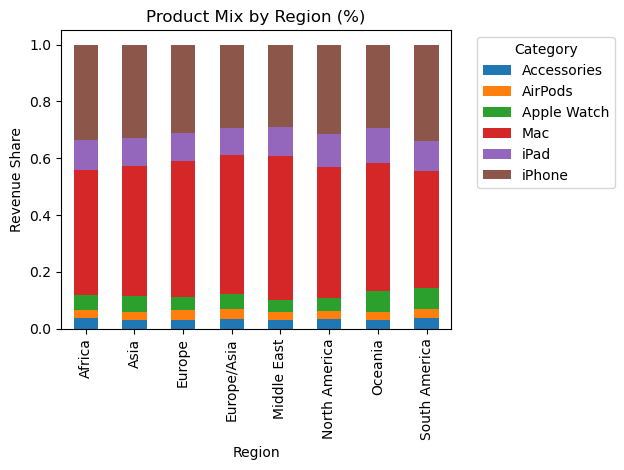

In [40]:
mix = (
    df.groupby(["region", "category"])["revenue_usd"]
    .sum()
    .unstack()
)

mix_pct = mix.div(mix.sum(axis=1), axis=0)

mix_pct.plot(kind="bar", stacked=True)
plt.title("Product Mix by Region (%)")
plt.xlabel("Region")
plt.ylabel("Revenue Share")
plt.legend(title="Category", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

## WHAT DO I GET FOR THIS BUSINESS INSIGHT ? ##
### Business Intelligence / Descriptive Analytics Project ###
###### Awalnya proyek ini saya coba untuk membuat model prediksi.
###### Tapi karna hasil evaluasi nya menunjukkan akurasi mendekati acak
###### (ROC-AUC ~0.50 dan R² negatif), jadinya prediksi kurang layak digunakan.
###### Karna itu, fokus proyek ini saya gantikan ke analisis struktur bisnis saja.

#### Hasil utama:
###### - Mac menyumbang ~46% dan iPhone ~32% dari total pendapatan
######   (total gabungan ~78%).
###### - Konsentrasi produk rendah (HHI ~0.068), artinya risiko ketergantungan kecil.
###### - Eropa (34%) dan Asia (30%) adalah pasar utama dengan total kontribusi sekitar 65%.
###### - Nilai penjualan per unit tertinggi ada di Timur Tengah (~839), menunjukkan daya beli dan positioning premium yang kuat.
###### - Komposisi produk di setiap wilayah nya relatif konsisten, dengan Mac selalu di atas 40% kontribusi.

#### Kesimpulan:
###### - Struktur bisnis stabil dan terdiversifikasi dengan baik.
###### - Mac jadi tulang punggung pendapatan global.